In [161]:
import matplotlib.pyplot as plt
import numpy as np
import sounddevice as sd

# настройки графиков
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["lines.linewidth"] = 1.5
plt.rcParams["axes.grid"] = True


In [162]:
# исходные данные

# обой C5
A = [1, 0.5, 0.2, 0.1]
f0 = 523
h = [1, 2, 3, 4]
phi = 0

# параметры дискретизации
fs = 44100  # частота дискретизации
duration = 2  # длительность сигнала
N = int(duration * fs)  # кол-во отсчетов
N_plot = 2048  # кол-во отсчетов для визуализации
t = np.arange(N) / fs  # временная ось
omega = np.linspace(0, np.pi, 1000)  # ось для АЧХ


In [163]:
# генерация сигнала


def generate_signal(A, h, f0, phi, t):
    signals = [
        Ai * np.sin(2 * np.pi * hi * f0 * t + phi) for Ai, hi in zip(A, h, strict=True)
    ]
    return np.sum(signals, axis=0)


x = generate_signal(A, h, f0, phi, t)

# наложение шума
noise = 0.2 * np.random.randn(N)
x_noise = x + noise

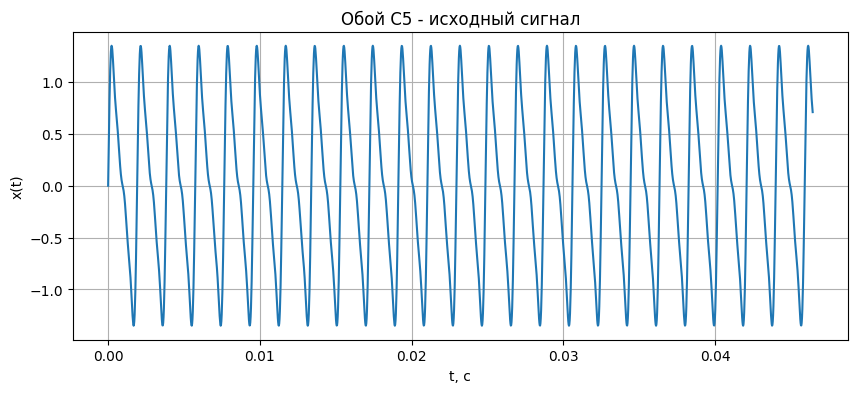

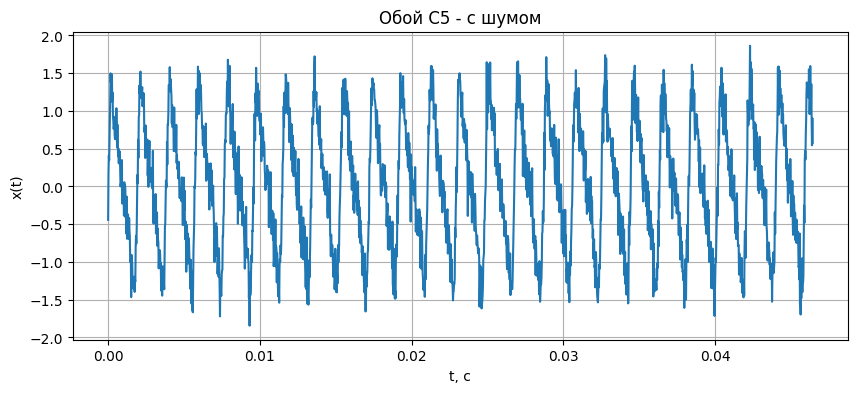

In [164]:
# графики исходного и изменного сигналов

plt.plot(t[:N_plot], x[:N_plot])
plt.title("Обой C5 - исходный сигнал")
plt.xlabel("t, с")
plt.ylabel("x(t)")
plt.show()

plt.plot(t[:N_plot], x_noise[:N_plot])
plt.title("Обой C5 - с шумом")
plt.xlabel("t, с")
plt.ylabel("x(t)")
plt.show()

In [165]:
# исходный сигнал
sd.play(x, samplerate=fs)
sd.wait()

# с шумом
sd.play(x_noise, samplerate=fs)
sd.wait()

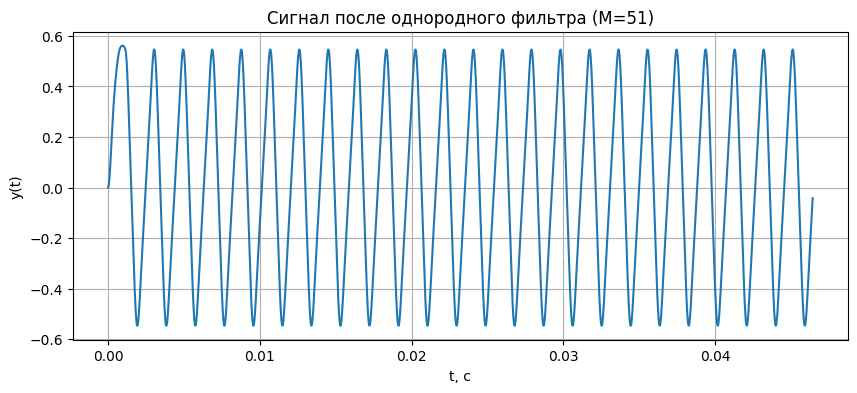

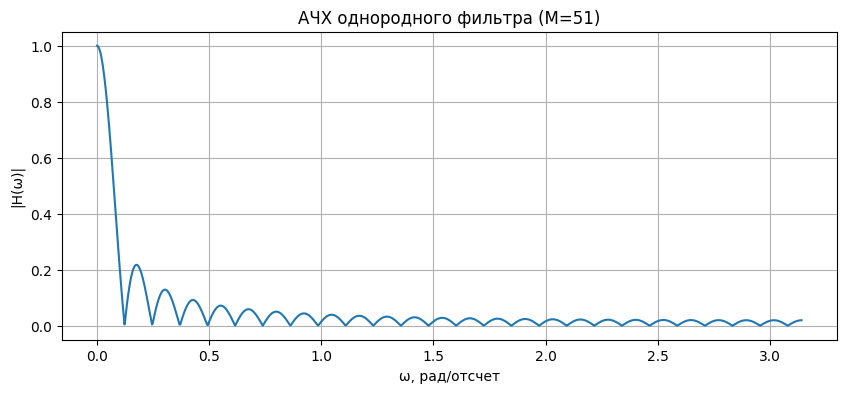

In [166]:
# однородный фильтр

M_mov_avg = 51
h_mov_avg = np.ones(M_mov_avg) / M_mov_avg
y_mov_avg = np.zeros(N)

for n in range(N):
    s = 0
    for k in range(min(n, M_mov_avg)):
        s += x[n - k]
    y_mov_avg[n] = s / M_mov_avg

plt.plot(t[:N_plot], y_mov_avg[:N_plot])
plt.title("Сигнал после однородного фильтра (M=51)")
plt.xlabel("t, с")
plt.ylabel("y(t)")
plt.show()

H_mov_avg = np.abs(
    np.sum(
        h_mov_avg[:, None]
        * np.exp(-1j * omega[None, :] * np.arange(M_mov_avg)[:, None]),
        axis=0,
    )
)

plt.plot(omega, H_mov_avg)
plt.title("АЧХ однородного фильтра (M=51)")
plt.xlabel("ω, рад/отсчет")
plt.ylabel("|H(ω)|")
plt.show()

In [167]:
sd.play(y_mov_avg, samplerate=fs)
sd.wait()

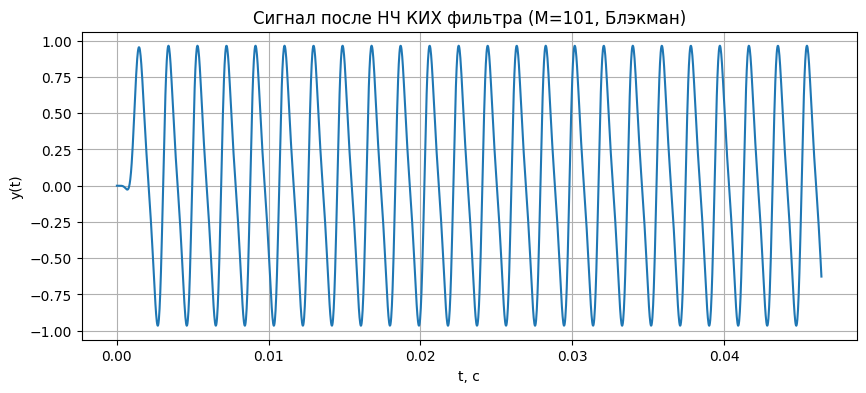

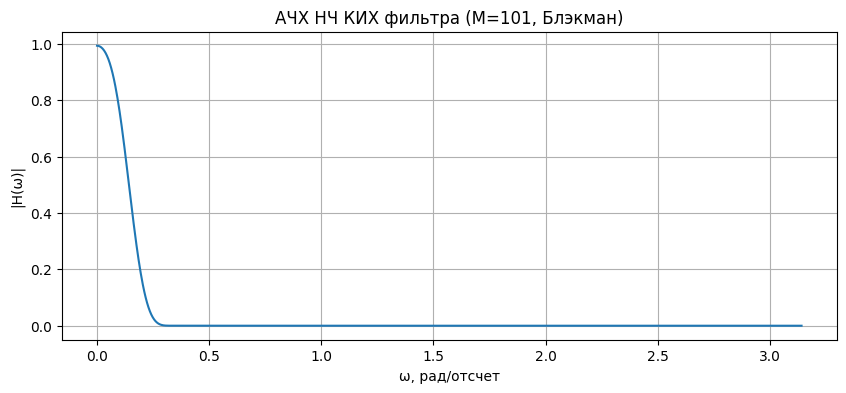

In [168]:
# КИХ фильтр

f_fir = 1000
M_fir = 101
n = np.arange(M_fir)

h_d = 2 * f_fir / fs * np.sinc(2 * f_fir / fs * (n - (M_fir - 1) / 2))
blackman = (
    0.42
    - 0.5 * np.cos(2 * np.pi * n / (M_fir - 1))
    + 0.08 * np.cos(4 * np.pi * n / (M_fir - 1))
)
h_fir = h_d * blackman

y_fir = np.zeros(N)
for n in range(N):
    s = 0
    for k in range(min(n, M_fir)):
        s += h_fir[k] * x[n - k]
    y_fir[n] = s

plt.plot(t[:N_plot], y_fir[:N_plot])
plt.title("Сигнал после НЧ КИХ фильтра (M=101, Блэкман)")
plt.xlabel("t, с")
plt.ylabel("y(t)")
plt.show()

H_fir = np.abs(
    np.sum(
        h_fir[:, None] * np.exp(-1j * omega[None, :] * np.arange(M_fir)[:, None]),
        axis=0,
    )
)

plt.plot(omega, H_fir)
plt.title("АЧХ НЧ КИХ фильтра (M=101, Блэкман)")
plt.xlabel("ω, рад/отсчет")
plt.ylabel("|H(ω)|")
plt.show()

In [169]:
sd.play(y_fir, samplerate=fs)
sd.wait()

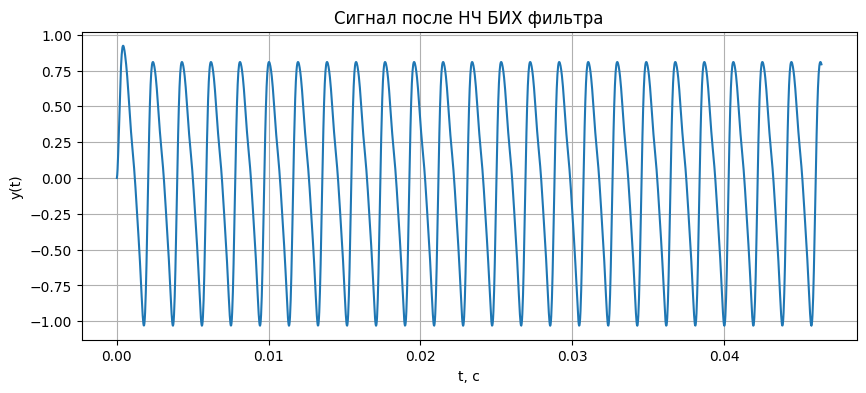

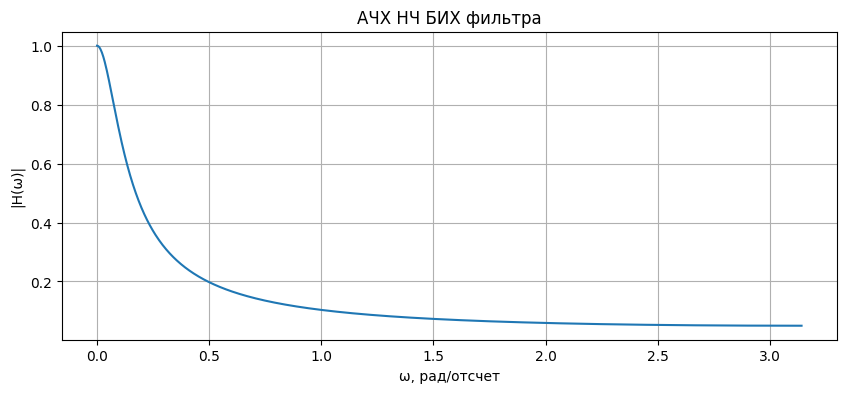

In [170]:
# БИХ фильтр

f_iir = 700
alpha = np.exp(-2 * np.pi * f_iir / fs)
a0 = 1 - alpha
b1 = alpha

y_iir = np.zeros(N)
y_iir[0] = a0 * x[0]

for n in range(1, N):
    y_iir[n] = a0 * x[n] + b1 * y_iir[n - 1]

plt.plot(t[:N_plot], y_iir[:N_plot])
plt.title("Сигнал после НЧ БИХ фильтра")
plt.xlabel("t, с")
plt.ylabel("y(t)")
plt.show()

H_iir = np.abs(a0 / (1 - b1 * np.exp(-1j * omega)))

plt.plot(omega, H_iir)
plt.title("АЧХ НЧ БИХ фильтра")
plt.xlabel("ω, рад/отсчет")
plt.ylabel("|H(ω)|")
plt.show()

In [171]:
sd.play(y_iir, samplerate=fs)
sd.wait()